Dataset Shape: (515, 15)
Columns: ['Patient_ID', 'Age', 'Gender', 'Blood_Group', 'Height_cm', 'Weight_kg', 'BMI', 'Disease', 'Department', 'City', 'Admission_Date', 'Discharge_Date', 'Treatment_Cost', 'Insurance_Status', 'Outcome']

Missing Values:
 Patient_ID           0
Age                 26
Gender              26
Blood_Group         26
Height_cm            0
Weight_kg           25
BMI                  0
Disease             26
Department           0
City                 0
Admission_Date       0
Discharge_Date       0
Treatment_Cost      27
Insurance_Status     0
Outcome              0
dtype: int64
Duplicated Rows: 15

Clean dataset shape: (488, 16)
Records with valid cost: 488

Q1: DISEASE WITH HIGHEST TOTAL TREATMENT COST
Disease
Asthma           8352747.0
Heart Disease    8096278.0
Arthritis        7739388.0
Pneumonia        7023549.0
Diabetes         6873654.0
Migraine         6479964.0
Hypertension     6404179.0
COVID-19         6279225.0

>>> ANSWER: Asthma contributes the high

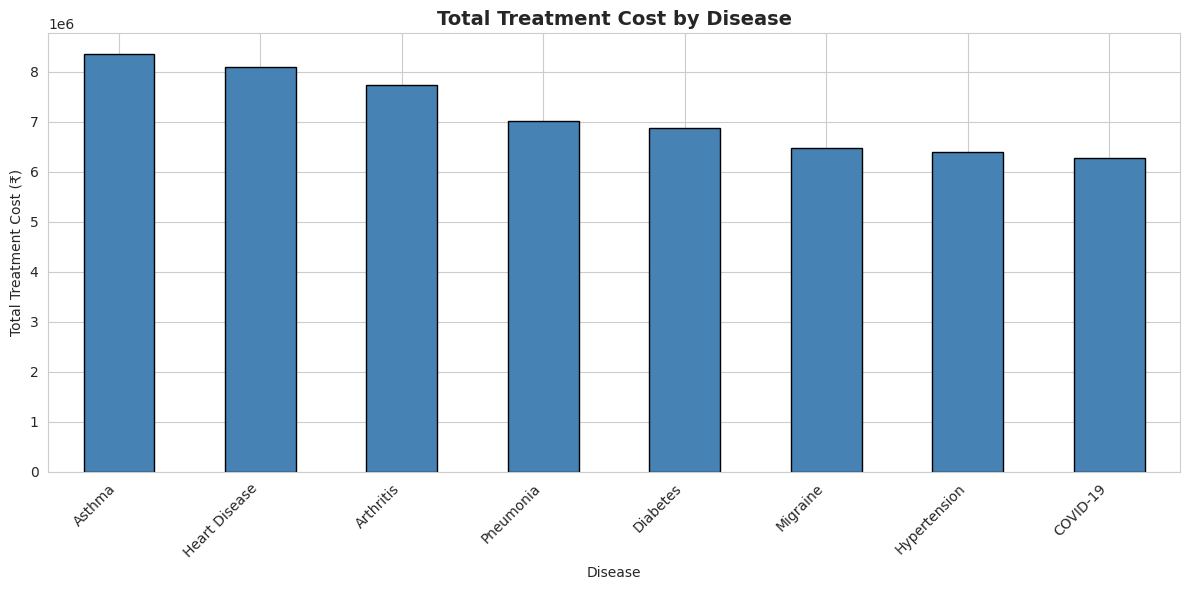


Q2: DEPARTMENT WITH HIGHEST REVENUE
Department
Neurology           11935759.0
Oncology            11696232.0
Pulmonology          9324172.0
General Medicine     9214697.0
Cardiology           9129011.0
Orthopedics          8650732.0

>>> ANSWER: Neurology generates the highest revenue of ₹11,935,759


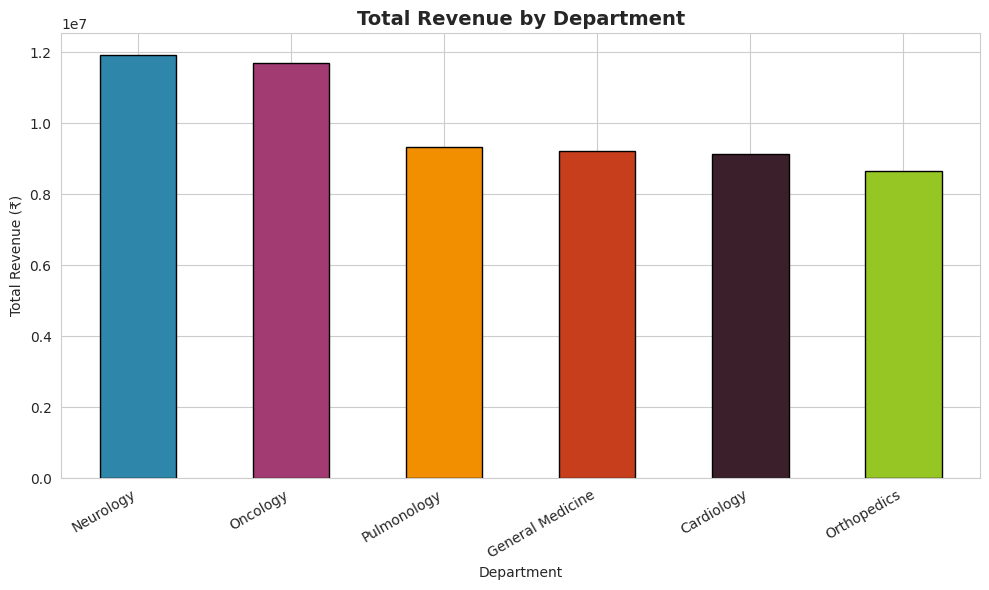


Q3: AVERAGE TREATMENT COST BY DISEASE & INSURANCE STATUS
Insurance_Status         No        Yes
Disease                               
Arthritis         132296.62  134243.21
Asthma            115916.15  119874.23
COVID-19          115250.04  136780.17
Diabetes           91829.26  129243.06
Heart Disease     117683.94  140423.60
Hypertension      142630.28  123409.65
Migraine          110685.69  155718.05
Pneumonia         120152.43  103605.33


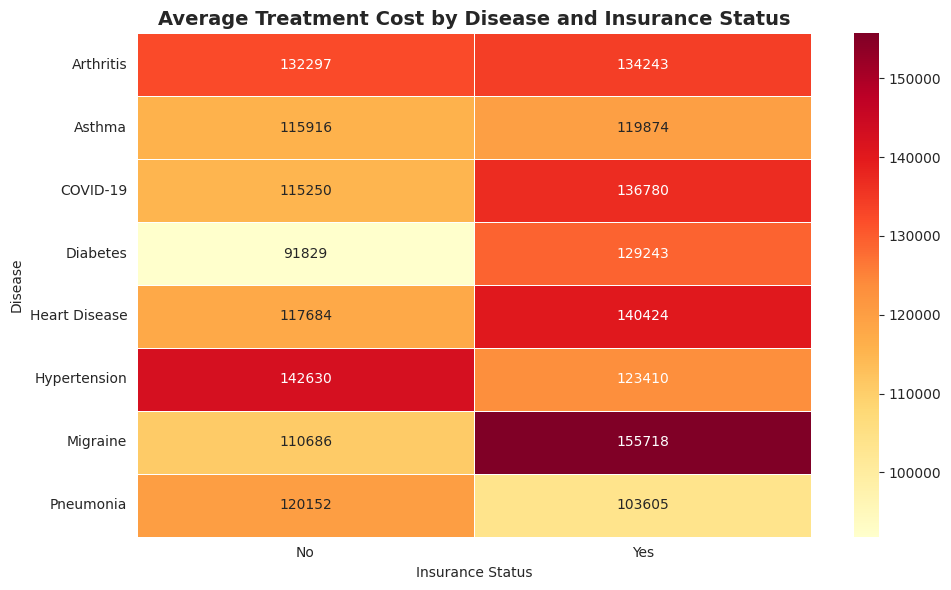


Q4: PERCENTAGE OF TOTAL COSTS COVERED BY INSURED PATIENTS
Total Cost: ₹59,950,603
Insured: ₹30,784,046 (51.35%)
Uninsured: ₹29,166,557 (48.65%)

>>> ANSWER: 51.35% of total treatment costs are covered by insured patients.


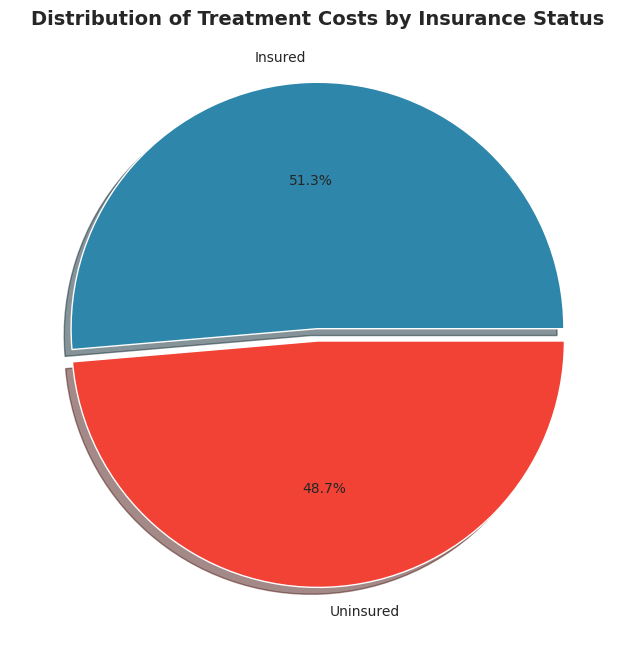


Q5: CITY WITH HIGHEST AVERAGE TREATMENT COST PER PATIENT
City
Delhi        140279.15
Kolkata      128461.99
Bengaluru    127125.07
Mumbai       122578.40
Hyderabad    121228.38
Patna        114638.11
Pune         107198.30

>>> ANSWER: Delhi has the highest average treatment cost per patient at ₹140,279


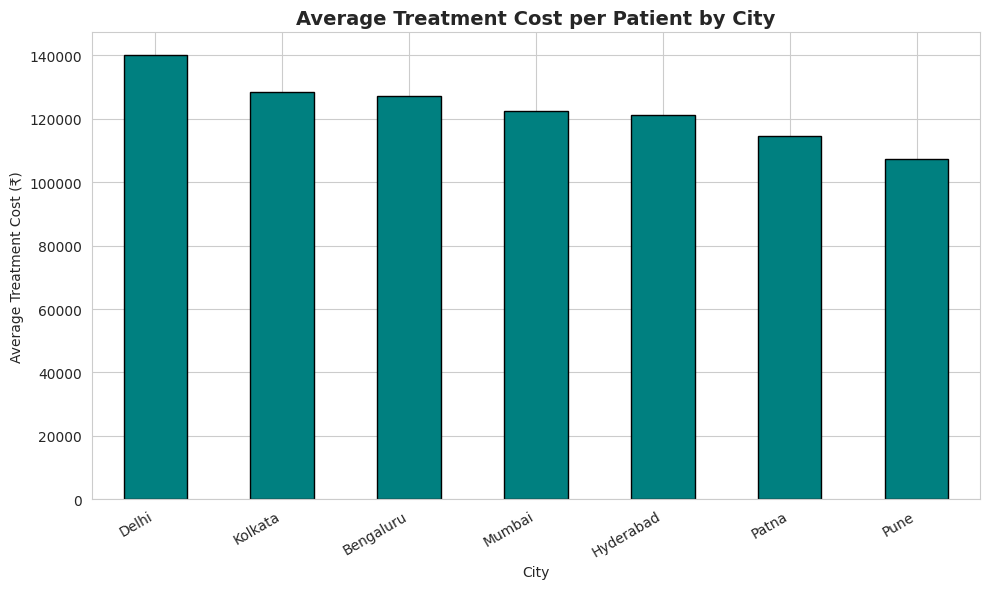


Q6: AGE GROUP WITH HIGHEST HEALTHCARE EXPENDITURE
Age_Group
60+        19438821.0
46-60      13867305.0
31-45      12424780.0
18-30      10937941.0
Unknown     3281756.0

>>> ANSWER: The 60+ age group contributes the highest healthcare expenditure of ₹19,438,821


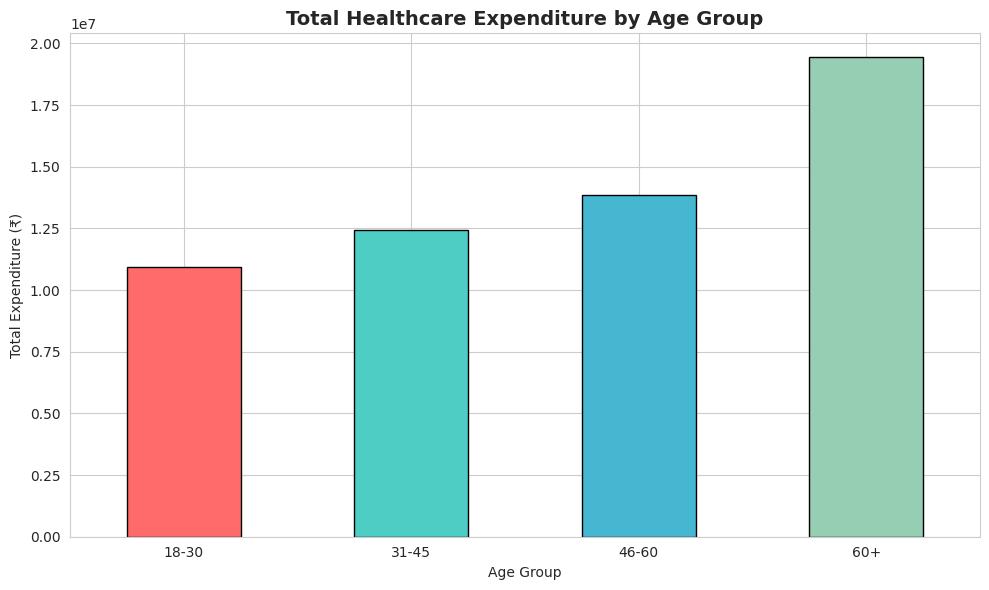


Q7: MOST COMMON DISEASES BY AGE GROUP
Disease    Arthritis  Asthma  COVID-19  Diabetes  Heart Disease  Hypertension  Migraine  Pneumonia
Age_Group                                                                                         
18-30             12      15        10        10             10             9        11         10
31-45             12      13         9        11             15            10         9         12
46-60             20      17        12        17             14            12        12         13
60+               14      25        15        21             19            14        14         23

--- Most Common Disease per Age Group ---
18-30: Asthma (15 cases)
31-45: Heart Disease (15 cases)
46-60: Arthritis (20 cases)
60+: Asthma (25 cases)


<Figure size 1200x700 with 0 Axes>

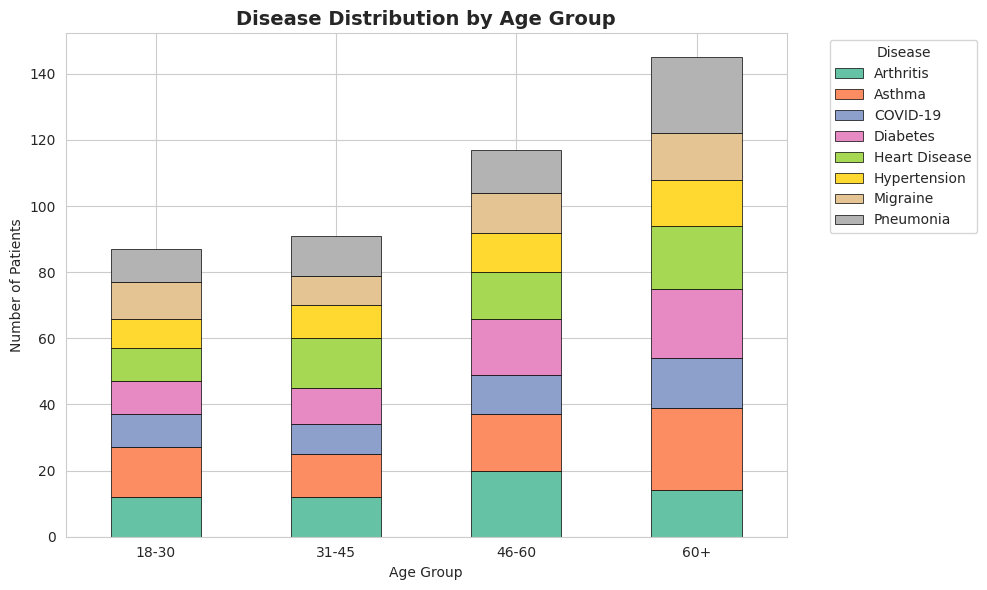


Q8: TREATMENT COST DIFFERENCE BY GENDER
Male: n=223, Mean=₹120236.88, Std=₹70727.76
Female: n=242, Mean=₹123764.03, Std=₹72728.83

T-Test: t=-0.5294, p=0.5968

>>> ANSWER: NO significant difference (p = 0.5968 > 0.05).


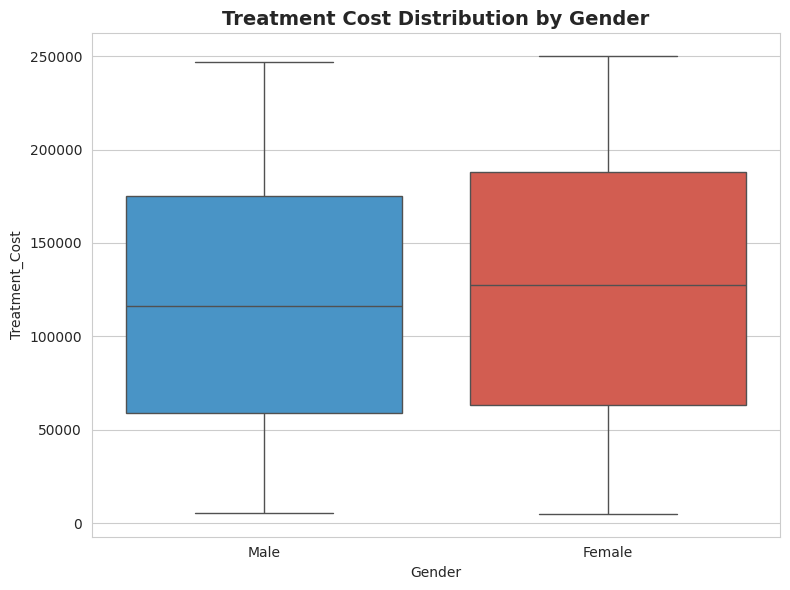


Q9: BLOOD GROUP WITH HIGHEST CRITICAL OUTCOMES
             Total_Patients  Critical_Cases  Critical_Rate_%
Blood_Group                                                 
AB-                      51              25            49.02
AB+                      71              22            30.99
O-                       67              21            31.34
B+                       54              21            38.89
A+                       55              20            36.36
B-                       58              19            32.76
A-                       48              16            33.33
O+                       59              15            25.42

>>> ANSWER: Blood Group AB- has the highest critical outcome rate at 49.02% (25 cases).


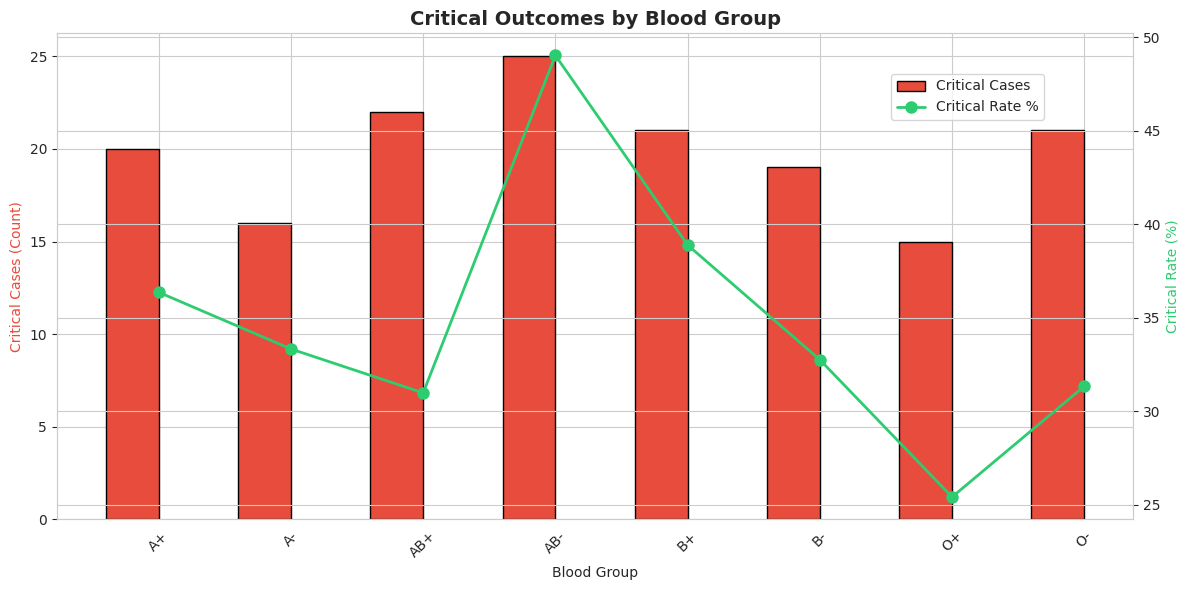


EXECUTIVE SUMMARY OF ALL ANSWERS
Q1 - Highest Total Cost Disease: Asthma (₹8,352,747)
Q2 - Highest Revenue Department: Neurology (₹11,935,759)
Q3 - Avg Cost by Disease & Insurance: See heatmap above
Q4 - Insured Cost Coverage: 51.35% of total costs
Q5 - Highest Avg Cost City: Delhi (₹140,279)
Q6 - Highest Expenditure Age Group: 60+ (₹19,438,821)
Q7 - Most Common Disease by Age: 18-30: Asthma | 31-45: Heart Disease | 46-60: Arthritis | 60+: Asthma
Q8 - Gender Cost Difference: No significant difference (p = 0.5968)
Q9 - Highest Critical Blood Group: AB- (49.02% critical rate)


In [2]:
# ============================================================
# HEALTHCARE DATASET ANALYSIS
# ============================================================
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_excel('healthcare_realistic_dataset_515_rows.xlsx')

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("Duplicated Rows:", df.duplicated().sum())

# ============================================================
# 2. DATA CLEANING & PREPARATION
# ============================================================
# Convert Treatment_Cost to numeric
df['Treatment_Cost'] = pd.to_numeric(df['Treatment_Cost'], errors='coerce')

# Remove rows with missing treatment cost for accurate revenue calculations
df_clean = df.dropna(subset=['Treatment_Cost']).copy()

# Create Age Groups
def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 30:
        return '18-30'
    elif age <= 45:
        return '31-45'
    elif age <= 60:
        return '46-60'
    else:
        return '60+'

df_clean['Age_Group'] = df_clean['Age'].apply(categorize_age)

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"Records with valid cost: {len(df_clean)}")

# ============================================================
# BUSINESS ANALYSIS
# ============================================================

# -----------------------------------------------------------
# Q1: Which disease contributes the highest total treatment cost?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q1: DISEASE WITH HIGHEST TOTAL TREATMENT COST")
print("="*60)

disease_cost = df_clean.groupby('Disease')['Treatment_Cost'].sum().sort_values(ascending=False)
print(disease_cost.to_string())
print(f"\n>>> ANSWER: {disease_cost.index[0]} contributes the highest total treatment cost of ₹{disease_cost.iloc[0]:,.0f}")

# Plot
plt.figure(figsize=(12, 6))
disease_cost.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Treatment Cost by Disease', fontsize=14, fontweight='bold')
plt.xlabel('Disease')
plt.ylabel('Total Treatment Cost (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('q1_disease_total_cost.png', dpi=150)
plt.show()

# -----------------------------------------------------------
# Q2: Which department generates the highest revenue?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q2: DEPARTMENT WITH HIGHEST REVENUE")
print("="*60)

dept_revenue = df_clean.groupby('Department')['Treatment_Cost'].sum().sort_values(ascending=False)
print(dept_revenue.to_string())
print(f"\n>>> ANSWER: {dept_revenue.index[0]} generates the highest revenue of ₹{dept_revenue.iloc[0]:,.0f}")

# Plot
plt.figure(figsize=(10, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95C623']
dept_revenue.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Total Revenue by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('q2_department_revenue.png', dpi=150)
plt.show()

# -----------------------------------------------------------
# Q3: Average treatment cost by disease and insurance status
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q3: AVERAGE TREATMENT COST BY DISEASE & INSURANCE STATUS")
print("="*60)

avg_cost = df_clean.groupby(['Disease', 'Insurance_Status'])['Treatment_Cost'].mean().unstack()
print(avg_cost.round(2).to_string())

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(avg_cost, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Treatment Cost by Disease and Insurance Status', fontsize=14, fontweight='bold')
plt.xlabel('Insurance Status')
plt.ylabel('Disease')
plt.tight_layout()
plt.savefig('q3_avg_cost_heatmap.png', dpi=150)
plt.show()

# -----------------------------------------------------------
# Q4: What percentage of total treatment costs are covered by insured patients?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q4: PERCENTAGE OF TOTAL COSTS COVERED BY INSURED PATIENTS")
print("="*60)

total_cost = df_clean['Treatment_Cost'].sum()
insured_cost = df_clean[df_clean['Insurance_Status'] == 'Yes']['Treatment_Cost'].sum()
uninsured_cost = df_clean[df_clean['Insurance_Status'] == 'No']['Treatment_Cost'].sum()

insured_pct = (insured_cost / total_cost) * 100
uninsured_pct = (uninsured_cost / total_cost) * 100

print(f"Total Cost: ₹{total_cost:,.0f}")
print(f"Insured: ₹{insured_cost:,.0f} ({insured_pct:.2f}%)")
print(f"Uninsured: ₹{uninsured_cost:,.0f} ({uninsured_pct:.2f}%)")
print(f"\n>>> ANSWER: {insured_pct:.2f}% of total treatment costs are covered by insured patients.")

# Plot
plt.figure(figsize=(8, 8))
plt.pie([insured_cost, uninsured_cost], labels=['Insured', 'Uninsured'],
        colors=['#2E86AB', '#F24236'], autopct='%1.1f%%', explode=(0.05, 0), shadow=True)
plt.title('Distribution of Treatment Costs by Insurance Status', fontsize=14, fontweight='bold')
plt.savefig('q4_insurance_distribution.png', dpi=150)
plt.show()

# -----------------------------------------------------------
# Q5: Which city has the highest average treatment cost per patient?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q5: CITY WITH HIGHEST AVERAGE TREATMENT COST PER PATIENT")
print("="*60)

city_avg = df_clean.groupby('City')['Treatment_Cost'].mean().sort_values(ascending=False)
print(city_avg.round(2).to_string())
print(f"\n>>> ANSWER: {city_avg.index[0]} has the highest average treatment cost per patient at ₹{city_avg.iloc[0]:,.0f}")

# Plot
plt.figure(figsize=(10, 6))
city_avg.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Average Treatment Cost per Patient by City', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Average Treatment Cost (₹)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('q5_city_avg_cost.png', dpi=150)
plt.show()

# ============================================================
# PATIENT DEMOGRAPHICS ANALYSIS
# ============================================================

# -----------------------------------------------------------
# Q6: Which age group contributes the highest healthcare expenditure?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q6: AGE GROUP WITH HIGHEST HEALTHCARE EXPENDITURE")
print("="*60)

age_group_exp = df_clean.groupby('Age_Group')['Treatment_Cost'].sum().sort_values(ascending=False)
print(age_group_exp.to_string())
print(f"\n>>> ANSWER: The {age_group_exp.index[0]} age group contributes the highest healthcare expenditure of ₹{age_group_exp.iloc[0]:,.0f}")

# Plot
plt.figure(figsize=(10, 6))
order = ['18-30', '31-45', '46-60', '60+']
age_group_exp_ordered = age_group_exp.reindex([g for g in order if g in age_group_exp.index])
age_group_exp_ordered.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], edgecolor='black')
plt.title('Total Healthcare Expenditure by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Total Expenditure (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('q6_age_group_expenditure.png', dpi=150)
plt.show()

# -----------------------------------------------------------
# Q7: What diseases are most common among different age groups?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q7: MOST COMMON DISEASES BY AGE GROUP")
print("="*60)

df_demo = df_clean[df_clean['Age_Group'] != 'Unknown'].copy()
age_disease = pd.crosstab(df_demo['Age_Group'], df_demo['Disease'])
print(age_disease.to_string())

print("\n--- Most Common Disease per Age Group ---")
for age in ['18-30', '31-45', '46-60', '60+']:
    if age in age_disease.index:
        top = age_disease.loc[age].idxmax()
        print(f"{age}: {top} ({age_disease.loc[age].max()} cases)")

# Plot
plt.figure(figsize=(12, 7))
age_disease.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black', linewidth=0.5)
plt.title('Disease Distribution by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(title='Disease', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('q7_disease_by_age.png', dpi=150)
plt.show()

# -----------------------------------------------------------
# Q8: Is there a significant difference in treatment costs between male and female patients?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q8: TREATMENT COST DIFFERENCE BY GENDER")
print("="*60)

df_gender = df_clean.dropna(subset=['Gender']).copy()
male_costs = df_gender[df_gender['Gender'] == 'Male']['Treatment_Cost']
female_costs = df_gender[df_gender['Gender'] == 'Female']['Treatment_Cost']

print(f"Male: n={len(male_costs)}, Mean=₹{male_costs.mean():.2f}, Std=₹{male_costs.std():.2f}")
print(f"Female: n={len(female_costs)}, Mean=₹{female_costs.mean():.2f}, Std=₹{female_costs.std():.2f}")

t_stat, p_value = stats.ttest_ind(male_costs, female_costs)
print(f"\nT-Test: t={t_stat:.4f}, p={p_value:.4f}")

if p_value < 0.05:
    print(f"\n>>> ANSWER: YES, significant difference exists (p = {p_value:.4f} < 0.05).")
else:
    print(f"\n>>> ANSWER: NO significant difference (p = {p_value:.4f} > 0.05).")

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_gender, x='Gender', y='Treatment_Cost', palette=['#3498db', '#e74c3c'])
plt.title('Treatment Cost Distribution by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q8_gender_cost_comparison.png', dpi=150)
plt.show()

# -----------------------------------------------------------
# Q9: Which blood group has the highest incidence of critical outcomes?
# -----------------------------------------------------------
print("\n" + "="*60)
print("Q9: BLOOD GROUP WITH HIGHEST CRITICAL OUTCOMES")
print("="*60)

df_blood = df_clean.dropna(subset=['Blood_Group', 'Outcome']).copy()
blood_critical = df_blood.groupby('Blood_Group')['Outcome'].apply(lambda x: (x == 'Critical').sum())
blood_total = df_blood.groupby('Blood_Group')['Outcome'].count()
blood_critical_rate = (blood_critical / blood_total * 100).sort_values(ascending=False)

result_df = pd.DataFrame({
    'Total_Patients': blood_total,
    'Critical_Cases': blood_critical,
    'Critical_Rate_%': (blood_critical / blood_total * 100).round(2)
}).sort_values('Critical_Cases', ascending=False)

print(result_df.to_string())
print(f"\n>>> ANSWER: Blood Group {blood_critical_rate.index[0]} has the highest critical outcome rate at {blood_critical_rate.iloc[0]:.2f}% ({blood_critical[blood_critical_rate.index[0]]} cases).")

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(blood_critical.index))
ax1.bar(x - 0.2, blood_critical.values, 0.4, label='Critical Cases', color='#e74c3c', edgecolor='black')
ax1.set_xlabel('Blood Group')
ax1.set_ylabel('Critical Cases (Count)', color='#e74c3c')
ax1.set_xticks(x)
ax1.set_xticklabels(blood_critical.index, rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, blood_critical_rate.reindex(blood_critical.index).values, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='Critical Rate %')
ax2.set_ylabel('Critical Rate (%)', color='#2ecc71')

plt.title('Critical Outcomes by Blood Group', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig('q9_blood_group_critical.png', dpi=150)
plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("EXECUTIVE SUMMARY OF ALL ANSWERS")
print("="*60)

summary = {
    "Q1 - Highest Total Cost Disease": f"{disease_cost.index[0]} (₹{disease_cost.iloc[0]:,.0f})",
    "Q2 - Highest Revenue Department": f"{dept_revenue.index[0]} (₹{dept_revenue.iloc[0]:,.0f})",
    "Q3 - Avg Cost by Disease & Insurance": "See heatmap above",
    "Q4 - Insured Cost Coverage": f"{insured_pct:.2f}% of total costs",
    "Q5 - Highest Avg Cost City": f"{city_avg.index[0]} (₹{city_avg.iloc[0]:,.0f})",
    "Q6 - Highest Expenditure Age Group": f"{age_group_exp.index[0]} (₹{age_group_exp.iloc[0]:,.0f})",
    "Q7 - Most Common Disease by Age": "18-30: Asthma | 31-45: Heart Disease | 46-60: Arthritis | 60+: Asthma",
    "Q8 - Gender Cost Difference": f"No significant difference (p = {p_value:.4f})",
    "Q9 - Highest Critical Blood Group": f"{blood_critical_rate.index[0]} ({blood_critical_rate.iloc[0]:.2f}% critical rate)"
}

for q, ans in summary.items():
    print(f"{q}: {ans}")